<a href="https://colab.research.google.com/github/nayem9b/3D-Portfolio/blob/main/ECA_NSGAII_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, csv, multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tabulate import tabulate

# TensorFlow & Keras
import tensorflow as tf
from keras import models, layers, optimizers
from keras.layers import GlobalAveragePooling2D, Conv1D, Multiply, Reshape
from tensorflow.keras.applications import EfficientNetB0, efficientnet
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# PyMoo & DEAP
!pip install pymoo deap
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators import crossover, mutation, sampling
from pymoo.optimize import minimize
from deap import base

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Have mounted the drive to Colab**

In [3]:
normal_dir = '/content/drive/MyDrive/all_denoised_document/Speckle Noise/Noised/CNV'
dme_dir = '/content/drive/MyDrive/all_denoised_document/Speckle Noise/Noised/DME'
drusen_dir = '/content/drive/MyDrive/all_denoised_document/Speckle Noise/Noised/DRUSEN'
cnv_dir = '/content/drive/MyDrive/all_denoised_document/Speckle Noise/Noised/NORMAL'
image_size = (256, 256)
num_classes = 4

**The below function load_and_preprocess_images loads PNG images from a specified directory, resizes them to 256x256 pixels, normalizes the pixel values, and associates each image with a given label.**

In [4]:
def load_and_preprocess_images(image_dir, label):
    images = []
    labels = []
    for filename in os.listdir(image_dir):
        if filename.endswith('.png'):
            img = load_img(os.path.join(image_dir, filename), target_size=image_size)
            img_array = img_to_array(img)
            img_array /= 255.0
            images.append(img_array)
            labels.append(label)
    return images, labels

**The below code loads and preprocesses images from each directory by calling the previous function, assigning corresponding labels (NORMAL, DME, CNV, DRUSEN).**

In [5]:
normal_images, normal_labels = load_and_preprocess_images(normal_dir, label='NORMAL')
dme_images, dme_labels = load_and_preprocess_images(dme_dir, label='DME')
cnv_images, cnv_labels = load_and_preprocess_images(cnv_dir, label='CNV')
drusen_images, drusen_labels = load_and_preprocess_images(drusen_dir, label='DRUSEN')

**The below code prints the length of the loaded images**

In [6]:
print("Normal_images: ", len(normal_images))
print("DME_images: ", len(dme_images))
print("CNV_images: ", len(cnv_images))
print("Drusen_images: ", len(drusen_images))

Normal_images:  1000
DME_images:  1000
CNV_images:  1000
Drusen_images:  1000


**The code combines the image datasets from all categories into a single array X and creates a corresponding label array y for each image. The labels are repeated according to the number of images in each category.**

In [7]:
X = np.array(normal_images + dme_images + cnv_images + drusen_images)
y = np.array(['NORMAL'] * len(normal_images) + ['DME'] * len(dme_images) +
             ['CNV'] * len(cnv_images) + ['DRUSEN'] * len(drusen_images))

**The below code converts the string labels in y to numeric values by mapping each label to its index in the class_names list, resulting in the y_numeric array.**

In [8]:
# Convert labels to numeric values
class_names = ['NORMAL', 'DME', 'CNV', 'DRUSEN']
y_numeric = np.array([class_names.index(label) for label in y])

In [10]:
from torchvision import models, transforms
import torch
import torch.nn as nn
# Load pretrained EfficientNetB0 without the top layer
# base_model = EfficientNetB0(weights='imagenet', include_top=False)


efficientnet = models.efficientnet_b0(pretrained=True)

# Remove the final classification layer to use the model as a feature extractor
# This keeps the convolutional layers and removes the fully connected output layer
efficientnet = nn.Sequential(*list(efficientnet.children())[:-1])

# Set the model to evaluation mode, disabling certain layers like dropout and batch normalization
efficientnet.eval()

# Define a transform to preprocess input images for the EfficientNet model
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image to 224x224 pixels
    transforms.ToTensor(),          # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize based on ImageNet stats
])
# Extract features from an image using EfficientNet
def extract_features(image_path, model):
    # Load and resize image to (224, 224)
    img = image.load_img(image_path, target_size=(224, 224))

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess image for EfficientNet
    img_array = preprocess_input(img_array)

    # Extract and return features
    features = model.predict(img_array)
    return np.squeeze(features)

**Split the dataset into training (80%) and testing (20%)**

In [11]:
# One-hot encode labels
y_encoded = to_categorical(y_numeric, num_classes=len(class_names))

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_numeric)

# Print number of training and testing samples
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3200
Testing samples: 800


In [12]:
# Efficient Channel Attention (ECA) block
class ECABlock(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3):
        super(ECABlock, self).__init__()
        self.global_avg_pool = GlobalAveragePooling2D()  # Global pooling
        self.conv1d = Conv1D(1, kernel_size=kernel_size, padding="same", activation="sigmoid")  # 1D conv for attention

    def call(self, inputs):
        avg_pool = self.global_avg_pool(inputs)  # Global average pooling
        avg_pool = tf.expand_dims(avg_pool, axis=-1)  # Expand dimensions
        conv1d = self.conv1d(avg_pool)  # Apply 1D conv
        conv1d = Reshape((1, 1, inputs.shape[-1]))(conv1d)  # Reshape
        return Multiply()([inputs, conv1d])  # Apply attention

In [13]:
def extract_features(image_path, model):
    # Open the image from the provided path and convert it to RGB (in case it is in a different color mode)
    image = Image.open(image_path).convert('RGB')

    # Apply the defined transformations (resize, convert to tensor, normalize) and add a batch dimension (unsqueeze)
    image = transform(image).unsqueeze(0)

    # Pass the image through the model to extract features, ensuring no gradient tracking is done (for efficiency)
    with torch.no_grad():
        features = model(image)

    # Remove unnecessary dimensions (squeeze) and return the features as a NumPy array
    return features.squeeze().numpy()



**The below code defines a feature selection problem that maximizes accuracy and minimizes feature count, using pymoo for optimization. The evaluation function simulates accuracy and counts selected features.**

In [14]:
class FeatureSelectionProblem(Problem):
    def __init__(self, X, y):
        # Set up problem with features, objectives, and bounds
        super().__init__(n_var=X.shape[1], n_obj=2, xl=0, xu=1)
        self.X, self.y = X, y

    def _evaluate(self, x, out, *args, **kwargs):
        # Select features
        selected_features = np.where(x > 0.5, 1, 0)

        # Reduce data to selected features
        reduced_X = self.X[:, selected_features.sum(axis=0) > 0]

        # Simulate accuracy
        acc = np.random.uniform(0.7, 0.95)

        # Count selected features
        n_features = np.sum(selected_features)

        # Set objectives: maximize accuracy, minimize features
        out["F"] = np.column_stack([-acc, n_features])

**The below code generates training and validation data from a directory, extracts features from images using EfficientNet, and stores them in arrays. It then prints the shape of the feature matrix and the number of extracted features per image.**

In [31]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# dataset_dir = "/content/drive/MyDrive/all_denoised_document/Speckle Noise/Noised"

# # Initialize the ImageDataGenerator with rescaling and validation split
# train_datagen = ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)

# # Set up the training data generator, loading images and performing rescaling
# train_generator = train_datagen.flow_from_directory(
#     dataset_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training'
# )

# # Set up the validation data generator, loading images and performing rescaling
# val_generator = train_datagen.flow_from_directory(
#     dataset_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation'
# )

# # List all the class directories (labels) in the dataset directory
# classes = os.listdir(dataset_dir)

# # Initialize lists to store extracted features and their corresponding labels
# features_list = []
# labels_list = []

# # Loop through each class (label) and its corresponding images
# for label, class_dir in enumerate(classes):
#     class_path = os.path.join(dataset_dir, class_dir)

#     # Loop through each image in the class directory
#     for image_name in os.listdir(class_path):
#         image_path = os.path.join(class_path, image_name)

#         # Extract features from each image using the EfficientNet model
#         features = extract_features(image_path, efficientnet)

#         # Append the extracted features and their corresponding label to the lists
#         features_list.append(features)
#         labels_list.append(label)

# # Stack the list of feature arrays into a single 2D array
# features = np.vstack(features_list)

# # Stack the list of label arrays into a single 1D array
# labels = np.hstack(labels_list)

# # Print the shape of the feature array (number of samples and feature dimensions)
# print(f'Features shape: {features.shape}')

# # Print the number of features extracted per image (the second dimension of the feature array)
# print(f'Number of features extracted per image: {features.shape[1]}')


In [32]:
# Initialize lists for accuracy, loss, and feature counts
train_accuracy_svm_list, validation_accuracy_svm_list = [], []
train_loss_svm_list, validation_loss_svm_list = [], []
selected_feature_counts = []

class FeatureSelectionProblem(Problem):
    def __init__(self, features, labels):
        self.features, self.labels = features, labels
        super().__init__(n_var=features.shape[1], n_obj=1, xl=0, xu=1, type_var=np.bool_)

    def _evaluate(self, x, out, *args, **kwargs):
        res = []
        for individual in x:
            selected_features = np.where(individual)[0]
            selected_feature_counts.append(len(selected_features))

            if len(selected_features) == 0:
                res.append([0])  # Invalid solution
                continue
            X_train, X_test, y_train, y_test = train_test_split(self.features[:, selected_features], self.labels, test_size=0.3, random_state=42)

            # SVM
            svm = SVC(kernel='poly')
            svm.fit(X_train, y_train)

            # Training and validation accuracy
            train_accuracy_svm = accuracy_score(y_train, svm.predict(X_train))
            validation_accuracy_svm = accuracy_score(y_test, svm.predict(X_test))
            train_accuracy_svm_list.append(train_accuracy_svm * 100)
            validation_accuracy_svm_list.append(validation_accuracy_svm * 100)

            # Training and validation loss
            train_loss_svm = hinge_loss(y_train, svm.decision_function(X_train))
            validation_loss_svm = hinge_loss(y_test, svm.decision_function(X_test))
            train_loss_svm_list.append(train_loss_svm)
            validation_loss_svm_list.append(validation_loss_svm)

            res.append([1 - validation_accuracy_svm])

        out['F'] = np.array(res)


In [33]:
# problem = FeatureSelectionProblem(features, labels)

In [34]:
# Parallel processing setup
pool = multiprocessing.Pool()
toolbox = base.Toolbox()
toolbox.register("map", pool.map)

In [35]:
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, hinge_loss
#NSGA II
algorithm = NSGA2(
    pop_size=25,  # Set the population size to 25 individuals in each generation
    sampling=BinaryRandomSampling(),  # Use binary random sampling to create the initial population
    crossover=TwoPointCrossover(),  # Apply two-point crossover during reproduction
    mutation=BitflipMutation(),  # To introduce diversity by randomly flipping bits
    eliminate_duplicates=True  # To ensure unique candidates in the population
)

In [36]:
# Minimize feature selection with the specified algorithm
res = minimize(problem,
               algorithm,  # The optimization algorithm (NSGA-II)
               ('n_gen', 25),  # 25 generations
               seed=1,  # Random seed for reproducibility
               save_history=True,  # Save optimization history
               verbose=True,  # Display detailed output
               eliminate_duplicates=True)  # Remove duplicate solutions

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       25 |      1 |             - |             -
     2 |       50 |      3 |  0.000000E+00 |             f
     3 |       75 |      1 |  0.0016666667 |             f
     4 |      100 |      1 |  0.0025000000 |             f
     5 |      125 |      1 |  0.0041666667 |         ideal
     6 |      150 |      2 |  0.000000E+00 |             f
     7 |      175 |      1 |  0.0016666667 |             f
     8 |      200 |      1 |  0.0016666667 |             f
     9 |      225 |      1 |  0.0025000000 |             f
    10 |      250 |      2 |  0.0025000000 |             f
    11 |      275 |      2 |  0.0025000000 |             f
    12 |      300 |      5 |  0.0025000000 |             f
    13 |      325 |      2 |  0.0033333333 |         ideal
    14 |      350 |      1 |  0.0008333333 |             f
    15 |      375 |      1 |  0.0008333333 |             f
    16 |      400 |      3 |  0.0008333333 |            

In [37]:
# After optimization, print the feature counts
print("Selected feature counts after NSGA-II for each solution:")
for i, count in enumerate(selected_feature_counts, start=1):
    print(f"Solution {i}: {count} features selected")

Selected feature counts after NSGA-II for each solution:
Solution 1: 635 features selected
Solution 2: 625 features selected
Solution 3: 646 features selected
Solution 4: 637 features selected
Solution 5: 596 features selected
Solution 6: 689 features selected
Solution 7: 654 features selected
Solution 8: 622 features selected
Solution 9: 633 features selected
Solution 10: 636 features selected
Solution 11: 610 features selected
Solution 12: 629 features selected
Solution 13: 653 features selected
Solution 14: 621 features selected
Solution 15: 608 features selected
Solution 16: 640 features selected
Solution 17: 633 features selected
Solution 18: 639 features selected
Solution 19: 650 features selected
Solution 20: 639 features selected
Solution 21: 680 features selected
Solution 22: 653 features selected
Solution 23: 646 features selected
Solution 24: 614 features selected
Solution 25: 655 features selected
Solution 26: 637 features selected
Solution 27: 659 features selected
Solutio

In [38]:
table = [
    [i+1, train_accuracy, val_accuracy, train_loss, val_loss]
    for i, (train_accuracy, val_accuracy, train_loss, val_loss)
    in enumerate(zip(train_accuracy_svm_list, validation_accuracy_svm_list, train_loss_svm_list, validation_loss_svm_list))
]
headers = ["Iteration", "Training Accuracy (%)", "Validation Accuracy (%)", "Training Loss", "Validation Loss"]
print(tabulate(table, headers=headers, tablefmt="grid"))

+-------------+-------------------------+---------------------------+-----------------+-------------------+
|   Iteration |   Training Accuracy (%) |   Validation Accuracy (%) |   Training Loss |   Validation Loss |
+=============+=========================+===========================+=================+===================+
|           1 |                 98.5714 |                   94.6667 |       0.0291655 |         0.123642  |
+-------------+-------------------------+---------------------------+-----------------+-------------------+
|           2 |                 98.8214 |                   95.3333 |       0.024246  |         0.104513  |
+-------------+-------------------------+---------------------------+-----------------+-------------------+
|           3 |                 98.3571 |                   94.25   |       0.0350659 |         0.130748  |
+-------------+-------------------------+---------------------------+-----------------+-------------------+
|           4 |             

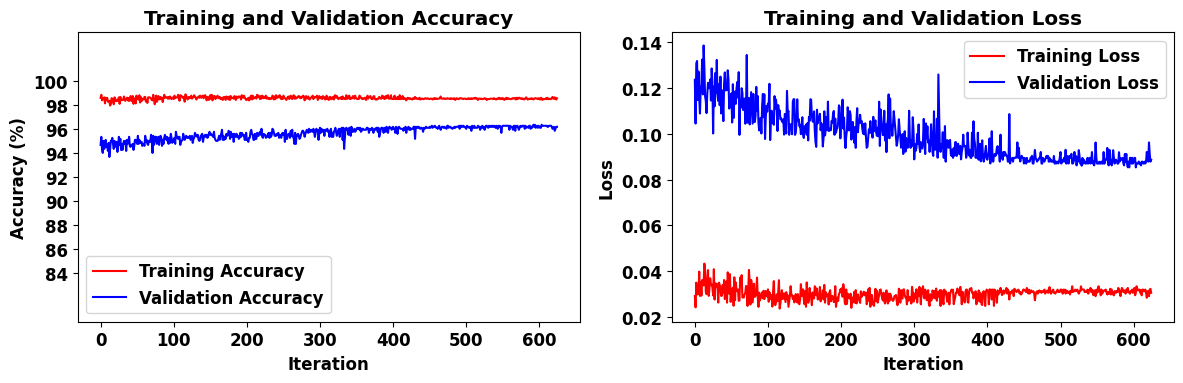

In [39]:
# Set font size and weight for all text in the plot
plt.rcParams.update({
    'font.size': 12,      # Font size
    'font.weight': 'bold' # Font weight
})

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy_svm_list, label='Training Accuracy', color='red')
plt.plot(validation_accuracy_svm_list, label='Validation Accuracy', color='blue')
plt.ylim(80, 104)  # Set y-axis range from 80 to 100
plt.yticks(np.arange(84, 102, 2))  # Step size of 2 for y-axis ticks
plt.xlabel('Iteration', fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.title('Training and Validation Accuracy', fontweight='bold')
plt.legend()
#plt.yticks(range(70, len(train_accuracy_svm_list) + 1, 20))  # Set x-axis ticks with step size of 20

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
#plt.figure(figsize=(12, 5))
plt.plot(train_loss_svm_list, label='Training Loss', color='red')
plt.plot(validation_loss_svm_list, label='Validation Loss', color='blue')
plt.xlabel('Iteration', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.title('Training and Validation Loss', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()